# 14 — Can anything detect the failure before it happens?

A head-to-head of detectors of the tutor's coming failure — **leak** (states the
final answer) and **exit** (calls `end_chat`) — on **identical rows**, all
**OUT-OF-FOLD**, presented on a **ROUND basis** (is *this turn* the one before
the failure?) and on a **TRIAL basis** (will *this conversation* fail at all?).
This notebook does no probe fitting: every score vector was written once by
`production/driftlab/probes_run.py` (library `driftlab/probes.py`) into
`results/probes/formal*-rows.npz`; here we only aggregate, bootstrap and draw.
The two new pieces (stated-plan items, node ceiling) are read from today's
`results/steer/*.json` cells and `results/nodes-supportive-k25.json`.

## Methods

**Rows.** One row per (trial, round *r*) with *r* strictly before the trial's
event; round-1 leaks excluded. `lead = event_round − r`. In the **supportive**
cell every trial ends in an event (80 leak trials, 40 exit trials), so
`will_leave` is the exact complement of `will_leak` there and "non-leak trials"
means "exit trials". Two **positions**: *assistant* = residual state at the end
of the tutor's reply at round *r*; *user* = state after the student's next
message (pre-decision). The user-position run only computed `will_leak`.

**Detectors (all scored out of fold, folds = persona×item groups, k=5):**
1. **ask-the-model** — a Qwen3.5-9B judge reads the visible transcript up to
   round *r* and states p_leak / p_leave (no fitting; "out of fold" trivially).
2. **introspection in the moment** — the tutor's private per-round self-report:
   (a) raw `−E[v]` (falling resolve; no fitting), (b) a 7-item logistic on the
   report items (OOF). Plus, new today, the **stated-plan items**
   `plan_answer` / `plan_leave` (0–10) written after the reply (§5).
3. **diff-in-means projection** of the residual stream at the modal layer
   (zero free parameters beyond the training-fold class means; OOF).
4. **linear probe** on the residual stream (nested layer/C selection inside each
   outer fold; OOF).
Floors: **text** (TF-IDF 1–2-grams of the conversation so far + persona one-hot,
round, cumulative reply length; OOF logistic) and **persona×round** (one-hot
persona, round and their product; OOF logistic — inside one persona cell this is
a *round-only prior*).

**Round basis** = round-conditional AUROC: positives at round *k* vs negatives at
round *k*, weighted by positives; the primary window counts only positives at
leads 1–3. **Trial basis** = collapse each trial's pre-event rows to one score
(max, and also mean) and compute AUROC leak-trials vs exit-trials. The trial
basis is partly "which item/persona" — a trial-level signal is *condition*, not
*decision* — so the persona×round floor is quoted next to every trial-basis
number, and note that a max over more rows favours longer trials.

**Uncertainty.** AUROCs carry a 95 % cluster bootstrap CI over persona×item
groups (rows resampled by group; trials resampled by item), n_boot = 300.
Means over rows/trials carry ± sd. Proportions carry Wilson 95 % intervals.
Every number is labelled **OOF** (out of fold) or **IN-SAMPLE**; only OOF
numbers count.

In [1]:
import sys, json, glob, os, datetime, warnings
sys.path.insert(0, "../production")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from driftlab.probes import auc, round_conditional_auc, bootstrap_groups, trial_level
from driftlab.intervene import _wilson
warnings.filterwarnings("ignore")
N_BOOT, SEED = 300, 0
R = {"assistant": json.load(open("../results/probes/formal.json")),
     "user": json.load(open("../results/probes/formal-user.json"))}
A = {"assistant": np.load("../results/probes/formal-rows.npz", allow_pickle=True),
     "user": np.load("../results/probes/formal-user-rows.npz", allow_pickle=True)}
METHODS = ["ask_llm", "report_neg_ev", "report_7item", "diffmean_proj", "probe", "text", "persona_round"]
LABEL = {"ask_llm": "1 ask-the-model (judge)", "report_neg_ev": "2a self-report −E[v]",
         "report_7item": "2b self-report 7-item", "diffmean_proj": "3 diff-in-means proj",
         "probe": "4 linear probe", "text": "floor: text TF-IDF", "persona_round": "floor: persona×round"}
CELLS = [("assistant", "will_leak"), ("assistant", "will_leave"), ("user", "will_leak")]   # primary first
for pos in R:
    P = R[pos]["provenance"]
    print(f"{pos:9s} run: started {P['started']} finished {P['finished']} | n_trials {P['n_trials']} | "
          f"grouping {P['grouping']} | k_outer {P['k_outer']} k_inner {P['k_inner']} | n_boot(driver) {P['n_boot']} n_perm {P['n_perm']} | quick={P['quick']}")
    blk = R[pos]["positions"][pos]
    print(f"          {blk['n_rows']} rows, {blk['n_r1_leaks_excluded']} round-1 leaks excluded; targets: {list(blk['targets'])}")

def cell_rows(pos, target):
    "Supportive-cell row arrays, aligned with the per-method OOF score vectors."
    Z = A[pos]; sup = Z[f"{pos}/persona"] == "supportive"
    d = {k: Z[f"{pos}/{k}"][sup] for k in ("rnd", "lead", "item", "trial", "group")}
    d["y"] = Z[f"{pos}/{target}"][sup]
    d["scores"] = {m: Z[f"{pos}/{target}/supportive/{m}"] for m in METHODS if f"{pos}/{target}/supportive/{m}" in Z}
    d["lead13"] = (d["lead"] >= 1) & (d["lead"] <= 3)
    return d

# -- inline checks on the loaded rows -------------------------------------------------
for pos, target in CELLS:
    d = cell_rows(pos, target); n = len(d["y"])
    assert n == 408, n
    for m, s in d["scores"].items():
        assert len(s) == n and np.all(np.isfinite(s)), (pos, target, m)
    folds = A[pos][f"{pos}/{target}/supportive/folds"]
    for g in np.unique(d["group"]): assert len(set(folds[d["group"] == g])) == 1, "a persona×item cell straddles folds"
    assert np.all(d["lead"] >= 1), "every supportive trial has an event (no lead = -1 rows)"
    print(f"[{pos}/{target}] {n} supportive rows, {int(d['y'].sum())} positive rows, {len(np.unique(d['trial']))} trials, "
          f"{len(np.unique(d['group']))} persona×item groups, methods: {list(d['scores'])}")
d1, d2 = cell_rows("assistant", "will_leak"), cell_rows("assistant", "will_leave")
assert np.array_equal(d1["y"], ~d2["y"]), "in the supportive cell will_leave must be the complement of will_leak"
assert np.array_equal(cell_rows("assistant", "will_leak")["trial"], cell_rows("user", "will_leak")["trial"]), "assistant/user rows aligned"
# judge coverage: the npz vector has no NaN; confirm the LATEST judge record for every supportive row is error-free
latest = {}
for line in open("../results/askllm/judge-qwen9b-self.jsonl"):
    if line.strip():
        j = json.loads(line); latest[(j["trial"], int(j["round"]))] = j
n_err_latest = sum(1 for t, r in zip(d1["trial"], d1["rnd"]) if latest[(t, int(r))].get("error"))
n_missing = sum(1 for t, r in zip(d1["trial"], d1["rnd"]) if (t, int(r)) not in latest)
print(f"judge: {len(latest)} (trial, round) keys; supportive rows missing a record {n_missing}, latest record errored {n_err_latest} "
      f"(driver meta says {R['assistant']['positions']['assistant']['targets']['will_leak']['supportive_rivals_meta']['judge_rows_errored']} errors were seen before re-judging)")
assert n_missing == 0 and n_err_latest == 0
print("checks passed")

assistant run: started 2026-09-02 14:13 finished 2026-09-02 14:30 | n_trials 360 | grouping persona x item | k_outer 5 k_inner 3 | n_boot(driver) 300 n_perm 20 | quick=False
          849 rows, 104 round-1 leaks excluded; targets: ['will_leak', 'will_leave']
user      run: started 2026-09-02 14:31 finished 2026-09-02 14:55 | n_trials 360 | grouping persona x item | k_outer 5 k_inner 3 | n_boot(driver) 300 n_perm 20 | quick=False
          849 rows, 104 round-1 leaks excluded; targets: ['will_leak']
[assistant/will_leak] 408 supportive rows, 211 positive rows, 120 trials, 24 persona×item groups, methods: ['ask_llm', 'report_neg_ev', 'report_7item', 'diffmean_proj', 'probe', 'text', 'persona_round']
[assistant/will_leave] 408 supportive rows, 197 positive rows, 120 trials, 24 persona×item groups, methods: ['ask_llm', 'report_neg_ev', 'report_7item', 'diffmean_proj', 'probe', 'text', 'persona_round']
[user/will_leak] 408 supportive rows, 211 positive rows, 120 trials, 24 persona×item grou

## 1. Summary table — primary cell (assistant position · will_leak · supportive), all OUT-OF-FOLD

Round basis = round-conditional AUROC over positives at leads 1–3 (the driver's
primary window); trial basis = AUROC of max-over-rows (and mean-over-rows) trial
scores, leak trials vs exit trials. CIs: cluster bootstrap over items.
The round-basis point estimates are recomputed here from the row vectors and
asserted equal to the numbers the driver wrote in `formal.json`.

In [2]:
def round_basis(d, m, idx=None):
    idx = np.arange(len(d["y"])) if idx is None else idx
    return round_conditional_auc(d["scores"][m][idx], d["y"][idx], d["rnd"][idx], pos_mask=d["lead13"][idx])[0]

def trial_basis(d, m, agg):
    ts, ty, ut = trial_level(d["scores"][m], d["y"], d["trial"], agg=agg)
    item_of_trial = np.array([d["item"][d["trial"] == t][0] for t in ut])
    return ts, ty, item_of_trial

def detector_table(pos, target, n_boot=N_BOOT):
    d = cell_rows(pos, target); rows = []
    stored = R[pos]["positions"][pos]["targets"][target]["supportive_rivals"]
    for m in METHODS:
        if m not in d["scores"]: continue
        rb = round_basis(d, m)
        assert abs(rb - stored[m]["leads_1_3"]) < 1e-9, (m, rb, stored[m]["leads_1_3"])
        lo, hi, _ = bootstrap_groups(lambda idx: round_basis(d, m, idx), d["group"], n_boot=n_boot, seed=SEED)
        row = {"method": LABEL[m], "round AUROC": rb, "round CI": (lo, hi)}
        for agg in ("max", "mean"):
            ts, ty, it = trial_basis(d, m, agg)
            tb = auc(ts, ty)
            tlo, thi, _ = bootstrap_groups(lambda idx: auc(ts[idx], ty[idx]), it, n_boot=n_boot, seed=SEED)
            row[f"trial-{agg} AUROC"] = tb; row[f"trial-{agg} CI"] = (tlo, thi)
        row["n_rows"] = len(d["y"]); row["n_pos_rows(l1-3)"] = int((d["y"] & d["lead13"]).sum())
        row["n_trials"] = len(np.unique(d["trial"])); row["n_pos_trials"] = int(trial_basis(d, m, "max")[1].sum())
        rows.append(row)
    return pd.DataFrame(rows).set_index("method"), d

def fmt(df):
    out = pd.DataFrame(index=df.index)
    for c in ("round", "trial-max", "trial-mean"):
        out[c] = [f"{a:.3f} [{lo:.2f}, {hi:.2f}]" for a, (lo, hi) in zip(df[f"{c} AUROC"], df[f"{c} CI"])]
    out.columns = ["ROUND basis AUROC [95% CI]", "TRIAL basis (max) AUROC [CI]", "TRIAL basis (mean) AUROC [CI]"]
    return out

TABLES = {}
for pos, target in CELLS:
    TABLES[(pos, target)], _ = detector_table(pos, target)
pos, target = CELLS[0]; T = TABLES[(pos, target)]
print(f"PRIMARY CELL — {pos} position · {target} · supportive — ALL OUT-OF-FOLD (folds = persona×item)")
print(f"round basis: {T['n_rows'].iloc[0]} rows, {T['n_pos_rows(l1-3)'].iloc[0]} positive rows at leads 1-3 | "
      f"trial basis: {T['n_trials'].iloc[0]} trials, {T['n_pos_trials'].iloc[0]} {target[5:]} trials | CI = cluster bootstrap over items, n_boot={N_BOOT}")
print(fmt(T).to_string())
print("\nPer-item persona×round floor on the trial basis is the number to beat for 'condition' (it knows only the round structure of each trial).")
# how much of the TRIAL basis is trial length?  (descriptive; the sign 'shorter -> leak' is read off the data, so treat as IN-SAMPLE)
d = cell_rows(pos, target); ut = np.unique(d["trial"])
nrows = np.array([(d["trial"] == t).sum() for t in ut]); ty = np.array([d["y"][d["trial"] == t][0] for t in ut]); ti = np.array([d["item"][d["trial"] == t][0] for t in ut])
a_len = auc(-nrows, ty); lo, hi, _ = bootstrap_groups(lambda idx: auc(-nrows[idx], ty[idx]), ti, n_boot=N_BOOT, seed=SEED)
print(f"\nTrial length alone (fewer pre-event rows -> leak; no model, sign read off the data = IN-SAMPLE): AUROC {a_len:.3f} [{lo:.2f}, {hi:.2f}]; "
      f"leak trials have {nrows[ty].mean():.2f} ± {nrows[ty].std():.2f} pre-event rows, exit trials {nrows[~ty].mean():.2f} ± {nrows[~ty].std():.2f}.")
print("The TRIAL-mean column of every method, floor included, sits at this number: on that basis the detectors are reading how long the conversation lasted.")

PRIMARY CELL — assistant position · will_leak · supportive — ALL OUT-OF-FOLD (folds = persona×item)
round basis: 408 rows, 179 positive rows at leads 1-3 | trial basis: 120 trials, 80 leak trials | CI = cluster bootstrap over items, n_boot=300
                        ROUND basis AUROC [95% CI] TRIAL basis (max) AUROC [CI] TRIAL basis (mean) AUROC [CI]
method                                                                                                       
1 ask-the-model (judge)         0.528 [0.48, 0.58]           0.461 [0.37, 0.55]            0.529 [0.41, 0.65]
2a self-report −E[v]            0.531 [0.42, 0.63]           0.544 [0.37, 0.71]            0.780 [0.58, 0.95]
2b self-report 7-item           0.251 [0.19, 0.34]           0.234 [0.15, 0.35]            0.767 [0.59, 0.93]
3 diff-in-means proj            0.571 [0.47, 0.66]           0.529 [0.39, 0.67]            0.818 [0.70, 0.92]
4 linear probe                  0.607 [0.54, 0.68]           0.662 [0.51, 0.80]            0.798

In [3]:
for pos, target in CELLS[1:]:
    T = TABLES[(pos, target)]
    print(f"\n{pos} position · {target} · supportive — ALL OUT-OF-FOLD  ({T['n_rows'].iloc[0]} rows, {T['n_pos_rows(l1-3)'].iloc[0]} pos rows at leads 1-3; "
          f"{T['n_trials'].iloc[0]} trials, {T['n_pos_trials'].iloc[0]} {target[5:]} trials)")
    print(fmt(T).to_string())
print("\nNote: in the supportive cell will_leave = NOT will_leak, so its trial basis is the mirror question (exit trials vs leak trials) scored by separately trained detectors.")


assistant position · will_leave · supportive — ALL OUT-OF-FOLD  (408 rows, 104 pos rows at leads 1-3; 120 trials, 40 leave trials)
                        ROUND basis AUROC [95% CI] TRIAL basis (max) AUROC [CI] TRIAL basis (mean) AUROC [CI]
method                                                                                                       
1 ask-the-model (judge)         0.564 [0.48, 0.65]           0.749 [0.56, 0.93]            0.751 [0.56, 0.92]
2a self-report −E[v]            0.505 [0.39, 0.63]           0.456 [0.29, 0.63]            0.220 [0.05, 0.42]
2b self-report 7-item           0.303 [0.22, 0.41]           0.766 [0.57, 0.94]            0.767 [0.59, 0.93]
3 diff-in-means proj            0.423 [0.31, 0.61]           0.737 [0.53, 0.92]            0.803 [0.67, 0.91]
4 linear probe                  0.428 [0.31, 0.52]           0.698 [0.50, 0.87]            0.711 [0.53, 0.87]
floor: text TF-IDF              0.461 [0.31, 0.63]           0.758 [0.55, 0.94]            0.747 [

### Figure 1 — round basis vs trial basis per method (OOF, 95 % cluster-bootstrap CIs)

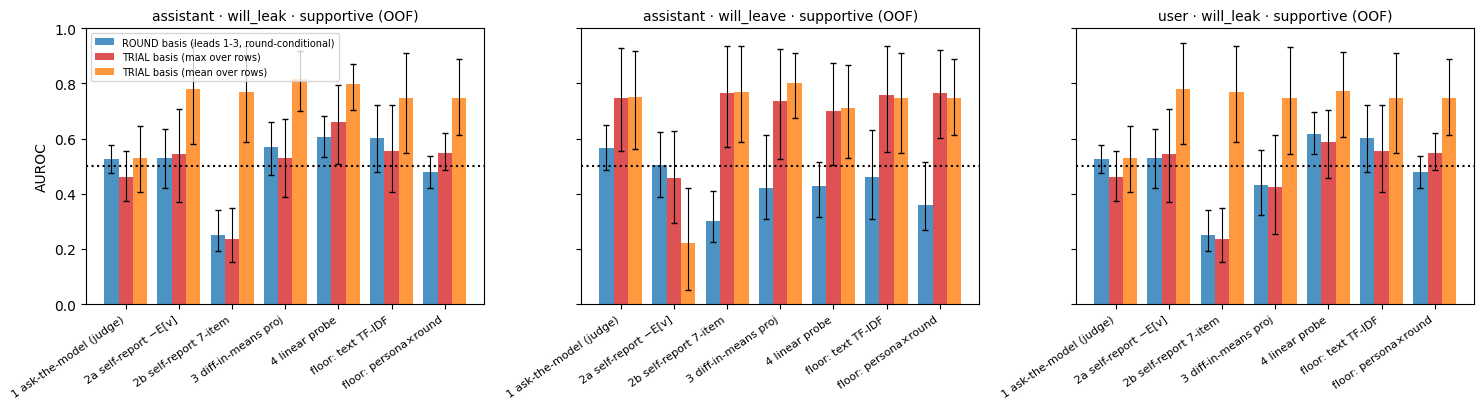

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (pos, target) in zip(axes, CELLS):
    T = TABLES[(pos, target)]; x = np.arange(len(T)); w = 0.27
    for j, (c, col) in enumerate((("round", "C0"), ("trial-max", "C3"), ("trial-mean", "C1"))):
        a = T[f"{c} AUROC"].values; ci = np.array(list(T[f"{c} CI"].values))
        ax.bar(x + (j - 1) * w, a, w, color=col, alpha=0.8, label={"round": "ROUND basis (leads 1-3, round-conditional)", "trial-max": "TRIAL basis (max over rows)", "trial-mean": "TRIAL basis (mean over rows)"}[c])
        ax.errorbar(x + (j - 1) * w, a, yerr=[a - ci[:, 0], ci[:, 1] - a], fmt="none", ecolor="k", lw=0.8, capsize=2)
    ax.axhline(0.5, ls=":", c="k"); ax.set_xticks(x); ax.set_xticklabels(T.index, rotation=35, ha="right", fontsize=8)
    ax.set_title(f"{pos} · {target} · supportive (OOF)", fontsize=10); ax.set_ylim(0, 1)
axes[0].set_ylabel("AUROC"); axes[0].legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()

## 2. Per-lead curves — every method, every cell (OOF)

Round-conditional AUROC for positives at exactly lead *ℓ* vs all same-round
negatives. Recomputed from the row vectors and checked against the driver's
`by_lead`. Positive counts per lead are printed (they thin out fast beyond
lead 3, so the CIs there are wide).

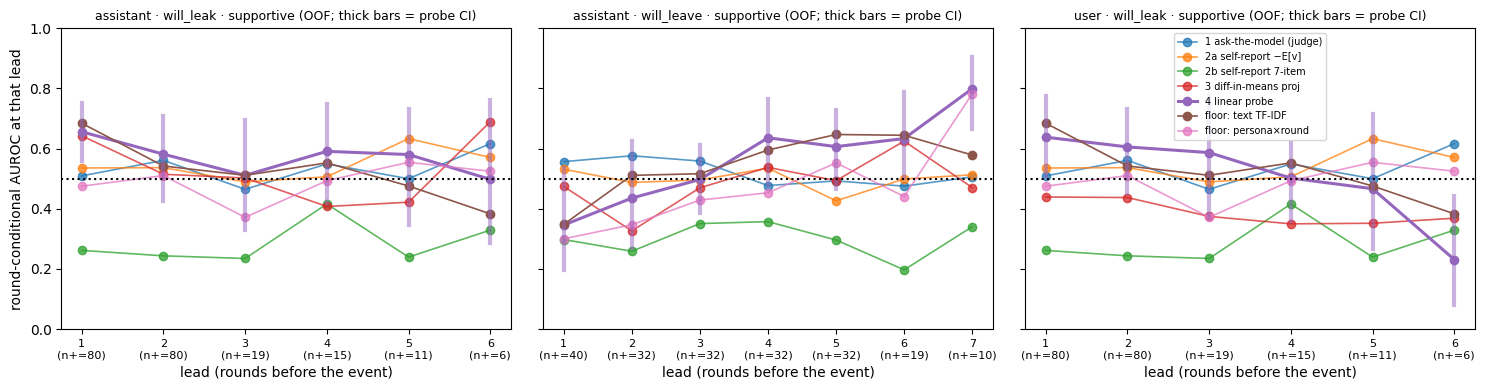

In [5]:
def by_lead(d, m, leads):
    return [round_conditional_auc(d["scores"][m], d["y"], d["rnd"], pos_mask=(d["lead"] == l))[0] for l in leads]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (pos, target) in zip(axes, CELLS):
    d = cell_rows(pos, target); stored = R[pos]["positions"][pos]["targets"][target]["supportive_rivals"]
    leads = sorted(int(k) for k in stored["probe"]["by_lead"])
    npos = [int((d["y"] & (d["lead"] == l)).sum()) for l in leads]
    for m in METHODS:
        if m not in d["scores"]: continue
        v = by_lead(d, m, leads)
        for l, a in zip(leads, v):
            if str(l) in stored[m]["by_lead"]: assert abs(a - stored[m]["by_lead"][str(l)]) < 1e-9, (m, l)
        ax.plot(leads, v, marker="o", label=LABEL[m], lw=2.2 if m == "probe" else 1.2, alpha=1 if m in ("probe", "text") else 0.75)
    prim = R[pos]["positions"][pos]["targets"][target]["supportive_primary"]
    for l, dd in prim["by_lead"].items(): ax.plot([int(l)] * 2, dd["ci"], c="C4", alpha=0.5, lw=3)
    ax.axhline(0.5, ls=":", c="k"); ax.set_xlabel("lead (rounds before the event)"); ax.set_xticks(leads)
    ax.set_xticklabels([f"{l}\n(n+={n})" for l, n in zip(leads, npos)], fontsize=8)
    ax.set_title(f"{pos} · {target} · supportive (OOF; thick bars = probe CI)", fontsize=9); ax.set_ylim(0, 1)
axes[0].set_ylabel("round-conditional AUROC at that lead"); axes[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 3. Per-round bars for the top-3 methods (primary cell, OOF)

At each round *k*: positives = will-leak rows at round *k* with lead ≤ 3,
negatives = every will-exit row at round *k*. Bars carry a cluster-bootstrap
CI over items; counts are printed under each round. This is where a
"round-2 tell" would show up.

assistant · will_leak · supportive — per-round AUROC (positives at leads 1-3), OOF, CI = cluster bootstrap over items (n_boot=300)
round   n+   n-          3 diff-in-means proj                4 linear probe            floor: text TF-IDF
    1   65   40              0.531 [0.37, 0.70]            0.626 [0.47, 0.77]            0.531 [0.37, 0.73]


    2   69   32              0.729 [0.57, 0.85]            0.704 [0.58, 0.81]            0.721 [0.58, 0.84]
    3   13   32              0.374 [0.23, 0.54]            0.412 [0.17, 0.65]            0.565 [0.37, 0.78]


    4   15   32              0.394 [0.24, 0.59]            0.510 [0.34, 0.69]            0.558 [0.38, 0.77]
    5   11   32              0.440 [0.23, 0.57]            0.372 [0.18, 0.63]            0.466 [0.26, 0.67]
    6    6   19              0.289 [0.03, 0.73]            0.395 [0.17, 0.75]            0.456 [0.25, 0.68]


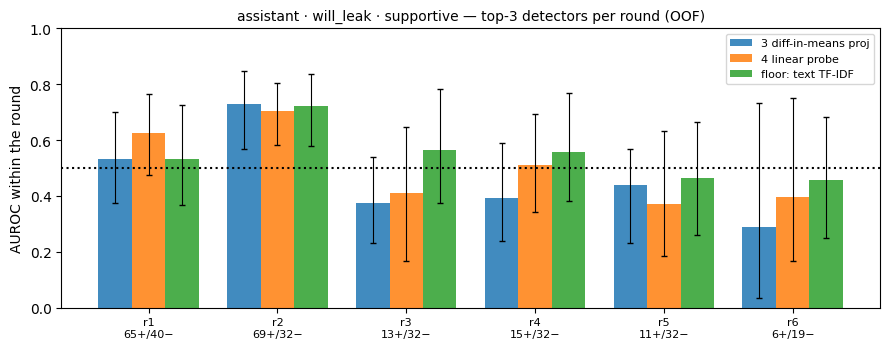

In [6]:
pos, target = CELLS[0]; d = cell_rows(pos, target); T = TABLES[(pos, target)]
top3 = [m for m in METHODS if LABEL[m] in T["round AUROC"].sort_values(ascending=False).index[:3]]
_, table = round_conditional_auc(d["scores"][top3[0]], d["y"], d["rnd"], pos_mask=d["lead13"])
rounds = [t[0] for t in table]
def rc_at(m, k, idx):
    sel = idx[d["rnd"][idx] == k]
    pos_ = d["scores"][m][sel][(d["y"] & d["lead13"])[sel]]; neg_ = d["scores"][m][sel][~d["y"][sel]]
    if len(pos_) < 3 or len(neg_) < 3: return np.nan
    return auc(np.concatenate([pos_, neg_]), np.r_[np.ones(len(pos_), bool), np.zeros(len(neg_), bool)])
print(f"{pos} · {target} · supportive — per-round AUROC (positives at leads 1-3), OOF, CI = cluster bootstrap over items (n_boot={N_BOOT})")
print(f"{'round':>5s} {'n+':>4s} {'n-':>4s}  " + "  ".join(f"{LABEL[m]:>28s}" for m in top3))
per_round = {m: [] for m in top3}
for k, _, npos, nneg in table:
    line = f"{k:5d} {npos:4d} {nneg:4d}  "
    for m in top3:
        a = rc_at(m, k, np.arange(len(d["y"])))
        lo, hi, _ = bootstrap_groups(lambda idx: rc_at(m, k, idx), d["group"], n_boot=N_BOOT, seed=SEED)
        per_round[m].append((a, lo, hi)); line += f"  {a:.3f} [{lo:.2f}, {hi:.2f}]".rjust(30)
    print(line)
fig, ax = plt.subplots(figsize=(9, 3.6)); x = np.arange(len(rounds)); w = 0.26
for j, m in enumerate(top3):
    v = np.array(per_round[m])
    ax.bar(x + (j - 1) * w, v[:, 0], w, label=LABEL[m], alpha=0.85)
    ax.errorbar(x + (j - 1) * w, v[:, 0], yerr=[v[:, 0] - v[:, 1], v[:, 2] - v[:, 0]], fmt="none", ecolor="k", lw=0.8, capsize=2)
ax.axhline(0.5, ls=":", c="k"); ax.set_xticks(x); ax.set_xticklabels([f"r{k}\n{n1}+/{n0}−" for k, _, n1, n0 in table], fontsize=8)
ax.set_ylim(0, 1); ax.set_ylabel("AUROC within the round"); ax.set_title(f"{pos} · {target} · supportive — top-3 detectors per round (OOF)", fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. The probe's layer curve with its permutation null band; direction stability

Blue: grouped-OOF round-conditional AUROC at every layer (C = 1, descriptive,
never used to pick the layer). Grey: trial-level label-permutation null, mean ± sd
over 20 permutations at the grid layers. Red ticks: layers chosen by the nested
folds. Below: split-half cosines of the probe direction (is the direction
reproducible?) and the persona swap (does it transfer?).

[assistant/will_leak] layer curve: max 0.644 at L32; modal nested layer L20, fold layer agreement 0.40; grid layers where the curve clears null mean+2sd: 4/5
    split-half at L20 (n=5): cos(probe_A, probe_B) = +0.06 ± 0.03 | cos(dm_A, dm_B) = +0.87 ± 0.03 | cos(probe, dm) = +0.11 ± 0.03
    persona swap supportive->neutral @L20: round-conditional 0.47 (pooled 0.53, n test rows 425)
    persona swap neutral->supportive @L20: round-conditional 0.50 (pooled 0.64, n test rows 408)
[assistant/will_leave] layer curve: max 0.559 at L20; modal nested layer L24, fold layer agreement 0.60; grid layers where the curve clears null mean+2sd: 0/5
    split-half at L24 (n=5): cos(probe_A, probe_B) = +0.09 ± 0.02 | cos(dm_A, dm_B) = +0.90 ± 0.02 | cos(probe, dm) = +0.10 ± 0.03
    persona swap supportive->neutral @L24: round-conditional 0.43 (pooled 0.49, n test rows 425)
    persona swap neutral->supportive @L24: round-conditional 0.53 (pooled 0.69, n test rows 408)
[user/will_leak] layer curve: max

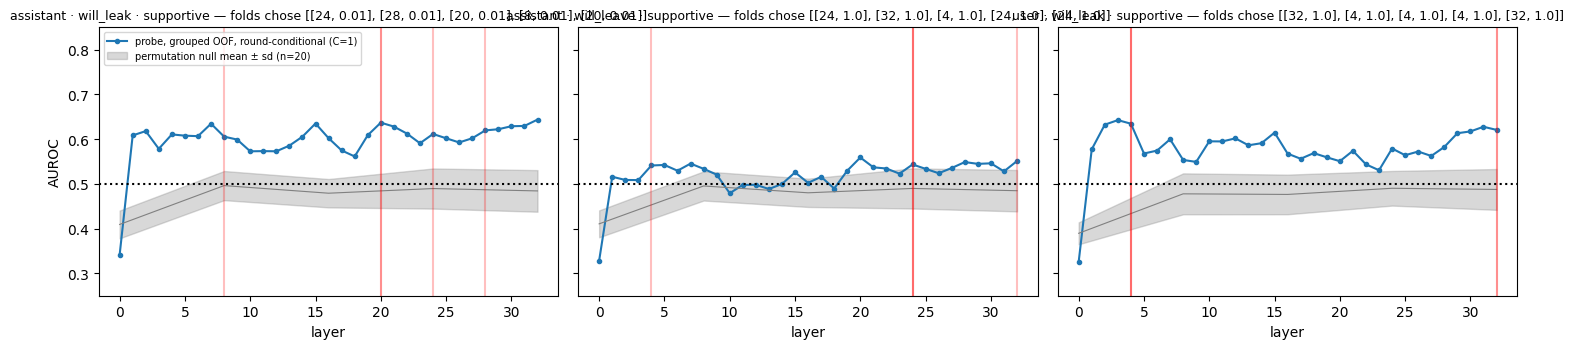

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, (pos, target) in zip(axes, CELLS):
    Z = A[pos]; k = f"{pos}/{target}/supportive"
    Ls, a = Z[f"{k}/layer_curve_layers"], Z[f"{k}/layer_curve"]
    nl, nm, ns = Z[f"{k}/null_layers"], Z[f"{k}/null_mean"], Z[f"{k}/null_sd"]
    ax.plot(Ls, a, marker=".", label="probe, grouped OOF, round-conditional (C=1)")
    ax.fill_between(nl, nm - ns, nm + ns, color="gray", alpha=0.3, label="permutation null mean ± sd (n=20)"); ax.plot(nl, nm, c="gray", lw=0.8)
    prim = R[pos]["positions"][pos]["targets"][target]["supportive_primary"]
    for L, C in prim["fold_choices"]: ax.axvline(L, color="red", alpha=0.25)
    ax.axhline(0.5, ls=":", c="k"); ax.set_xlabel("layer"); ax.set_ylim(0.25, 0.85)
    ax.set_title(f"{pos} · {target} · supportive — folds chose {prim['fold_choices']}", fontsize=9)
    above = int(np.sum(a[np.isin(Ls, nl)] > nm + 2 * ns))
    print(f"[{pos}/{target}] layer curve: max {a.max():.3f} at L{int(Ls[a.argmax()])}; modal nested layer L{prim['modal_layer']}, "
          f"fold layer agreement {prim['layer_agreement']:.2f}; grid layers where the curve clears null mean+2sd: {above}/{len(nl)}")
    st = R[pos]["positions"][pos]["targets"][target]["supportive_stability"]
    pp, dd, pdm = (np.array(st[q]) for q in ("probe_probe", "dm_dm", "probe_dm"))
    print(f"    split-half at L{st['layer']} (n={len(pp)}): cos(probe_A, probe_B) = {pp.mean():+.2f} ± {pp.std():.2f} | cos(dm_A, dm_B) = {dd.mean():+.2f} ± {dd.std():.2f} | cos(probe, dm) = {pdm.mean():+.2f} ± {pdm.std():.2f}")
    for q, sw in R[pos]["positions"][pos]["targets"][target]["persona_swap"].items():
        print(f"    persona swap {q} @L{sw['layer']}: round-conditional {sw['round_conditional']:.2f} (pooled {sw['pooled']:.2f}, n test rows {sw['n_test_rows']})")
axes[0].set_ylabel("AUROC"); axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 5. Introspection in the moment — the stated-plan items vs the next action

New today: after each reply the tutor privately rates `plan_answer` and
`plan_leave` (0–10). Score: the plan at round *r* vs the action actually taken
at round *r + 1* (`leak` / `leave`), pooled across every `results/steer/*.json`
cell that carries the plan keys (older cells with 7 items are skipped). Rank
AUROC with a cluster-bootstrap CI over (cell, item) trials; per-tier and
per-cell breakdowns; per-class mean ± sd of the stated plan. These are the
tutor's own statements, so no fitting and no folds — the AUROC is a direct
read-out, not a model.

In [8]:
files = sorted(f for f in glob.glob("../results/steer/*.json"))
pairs = []; used = []; skipped = []
for f in files:
    try: cell = json.load(open(f))
    except Exception as e: skipped.append((f, f"unreadable ({type(e).__name__})")); continue
    if "trials" not in cell: skipped.append((f, "no trials key")); continue
    tag = os.path.basename(f)[:-5]; n_pairs_f = 0
    for t in cell["trials"]:
        rs = t["rounds"]
        for a, b in zip(rs[:-1], rs[1:]):
            nt = a.get("note") or {}
            if nt.get("_unparsed") or nt.get("plan_leave") is None or nt.get("plan_answer") is None: continue
            pairs.append({"cell": tag, "persona": t["persona"], "tier": t["tier"], "item": f"{tag}/{t['item_id']}", "round": a["round"],
                          "plan_leave": float(nt["plan_leave"]), "plan_answer": float(nt["plan_answer"]), "next": b["action"]})
            n_pairs_f += 1
    mt = datetime.datetime.fromtimestamp(os.path.getmtime(f)).strftime("%H:%M")
    if n_pairs_f: used.append((f, mt, len(cell["trials"]), n_pairs_f))
    else: skipped.append((f, f"no plan keys (7-item cell, written {mt})"))
print("USED (file, written, trials, scored pairs):"); [print("  ", *u) for u in used]
print("SKIPPED:"); [print("  ", *s) for s in skipped]
PL = pd.DataFrame(pairs); assert len(PL) > 0
print(f"\n{len(PL)} (round r, round r+1) pairs with plan items; next action counts: {PL['next'].value_counts().to_dict()}")
# cross-check against the library's plan_predictor per cell
try:
    from driftlab.steer_summary import plan_predictor
    for f, *_ in used:
        c = json.load(open(f)); lib = plan_predictor(c); sub = PL[PL.cell == os.path.basename(f)[:-5]]
        assert lib["n_pairs"] == len(sub), (f, lib["n_pairs"], len(sub))
        if lib.get("auc_plan_leave_next_exit") is not None:          # None = a class is empty in that cell (e.g. 2 pairs)
            assert abs(lib["auc_plan_leave_next_exit"] - auc(sub.plan_leave, sub.next == "leave")) < 1e-9
    print("per-cell AUROCs agree with driftlab.steer_summary.plan_predictor")
except ImportError as e: print("steer_summary not importable, skipped cross-check:", e)

def plan_auc_row(sub, label):
    out = {"subset": label, "n_pairs": len(sub), "n_next_leave": int((sub.next == "leave").sum()), "n_next_leak": int((sub.next == "leak").sum())}
    it = sub.item.values
    for nm, s, y in (("plan_leave→exit", sub.plan_leave.values, (sub.next == "leave").values), ("plan_answer→leak", sub.plan_answer.values, (sub.next == "leak").values)):
        a = auc(s, y)
        if np.isnan(a): out[nm] = "n/a (empty class)"; continue
        lo, hi, _ = bootstrap_groups(lambda idx: auc(s[idx], y[idx]), it, n_boot=N_BOOT, seed=SEED)
        out[nm] = f"{a:.3f} [{lo:.2f}, {hi:.2f}]"
    return out
rows = [plan_auc_row(PL, "ALL cells pooled")]
rows += [plan_auc_row(PL[PL.tier == t], f"tier={t}") for t in sorted(PL.tier.unique())]
rows += [plan_auc_row(PL[PL.cell == c], f"cell={c}") for c in sorted(PL.cell.unique())]
print("\nStated plan at round r vs action at round r+1 — rank AUROC [95% cluster-bootstrap CI over trials] (direct read-out, no fitting):")
print(pd.DataFrame(rows).set_index("subset").to_string())
print("\nPer-class mean ± sd of the stated plans (0-10), by the action taken at the NEXT round:")
g = PL.groupby("next").agg(n=("plan_leave", "size"), plan_leave_mean=("plan_leave", "mean"), plan_leave_sd=("plan_leave", "std"),
                           plan_answer_mean=("plan_answer", "mean"), plan_answer_sd=("plan_answer", "std"))
print(g.round(2).to_string())
for nxt in ("leave", "leak"):
    sub = PL[PL.next == nxt]; col = "plan_leave" if nxt == "leave" else "plan_answer"
    kk = int((sub[col] >= 5).sum()); p, lo, hi = _wilson(kk, len(sub))
    print(f"rows whose NEXT action is {nxt:5s}: {kk}/{len(sub)} = {p:.2f} [Wilson {lo:.2f}, {hi:.2f}] stated {col} >= 5/10 the round before")

USED (file, written, trials, scored pairs):
   ../results/steer/aggressor__base__N1.json 13:30 24 35
   ../results/steer/aggressor__base__N1__axissupportive.json 14:49 24 5
   ../results/steer/aggressor__base__N1__d3.31__axissupportive.json 16:17 24 14
   ../results/steer/aggressor__base__N1__rep2.json 15:31 24 22
   ../results/steer/aggressor__base__none__rep2.json 15:20 24 2
   ../results/steer/aggressor__base__random.json 13:39 24 7
   ../results/steer/aggressor__base__random__seed1.json 14:27 24 22
   ../results/steer/aggressor__base__random__seed2.json 14:42 24 18
   ../results/steer/aggressor__noleak__none.json 12:22 24 48
   ../results/steer/aggressor__noleak_noleave__none.json 12:36 24 83
   ../results/steer/neutral__base__N1__d-1__axisaggressor.json 15:15 24 28
   ../results/steer/neutral__base__none.json 12:10 24 57
   ../results/steer/neutral__noleak__none.json 12:13 24 88
   ../results/steer/neutral__noleak_noleave__none.json 11:56 24 92
   ../results/steer/supportive__base


Stated plan at round r vs action at round r+1 — rank AUROC [95% cluster-bootstrap CI over trials] (direct read-out, no fitting):
                                                 n_pairs  n_next_leave  n_next_leak     plan_leave→exit    plan_answer→leak
subset                                                                                                                     
ALL cells pooled                                     780           198           77  0.631 [0.59, 0.67]  0.459 [0.40, 0.52]
tier=base                                            288            76           71  0.623 [0.56, 0.69]  0.473 [0.41, 0.55]
tier=noleak                                          234            65            1  0.662 [0.60, 0.72]  0.755 [0.71, 0.80]
tier=noleak_noleave                                  258            57            5  0.631 [0.56, 0.71]  0.778 [0.69, 0.90]
cell=aggressor__base__N1                              35            16            3  0.689 [0.55, 0.83]  0.318 [0.11, 0.57]
ce

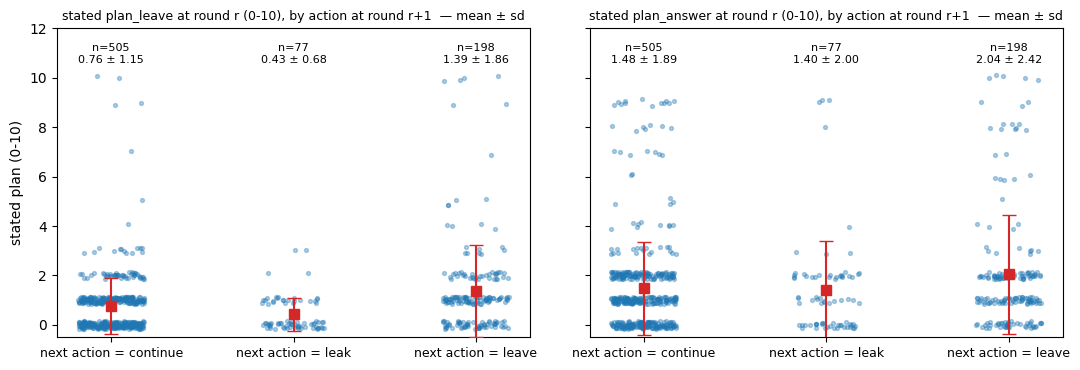

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
order = ["continue", "leak", "leave"]; rng = np.random.default_rng(0)
for ax, col in zip(axes, ("plan_leave", "plan_answer")):
    for i, nxt in enumerate(order):
        v = PL[PL.next == nxt][col].values
        if len(v) == 0: continue
        ax.scatter(i + rng.uniform(-0.18, 0.18, len(v)), v + rng.uniform(-0.15, 0.15, len(v)), s=8, alpha=0.35, c="C0")
        sd = v.std(ddof=1) if len(v) > 1 else 0.0     # ddof=1 to match the pandas table above
        ax.errorbar(i, v.mean(), yerr=sd, fmt="s", c="C3", capsize=5, ms=7, zorder=3)
        ax.text(i, 10.6, f"n={len(v)}\n{v.mean():.2f} ± {sd:.2f}", ha="center", fontsize=8)
    ax.set_xticks(range(3)); ax.set_xticklabels([f"next action = {o}" for o in order], fontsize=9); ax.set_ylim(-0.5, 12)
    ax.set_title(f"stated {col} at round r (0-10), by action at round r+1  — mean ± sd", fontsize=9)
axes[0].set_ylabel("stated plan (0-10)")
plt.tight_layout(); plt.show()

## 6. Ceiling context — how determined is the next action at a branch point?

`results/nodes-supportive-k25.json`: 47 supportive branch points (rounds 2–3),
each resampled 25 times from the same prefix. The node's own P(leak) / P(leave)
at that round is the best any state-based detector could do *at that prefix*
for a lead-1 call. A histogram, how many nodes sit near 0/1 vs mixed (Wilson
intervals per node), and — as an oracle bound, with the caveat that the
original trajectory was one greedy draw — the AUROC of node P(leak) against
the original trial's outcome.

model qwen3.5-9b: 47 supportive nodes, k=25 resamples each; rounds {2: 24, 3: 23}; original outcome leaked 36 / left 11
node P(leak)  mean ± sd over nodes = 0.28 ± 0.23 | P(leave) = 0.25 ± 0.08 | P(continue) = 0.47 ± 0.22
P(leak): near 0 (≤0.1) 19 nodes | near 1 (≥0.9) 0 | mixed (0.1-0.9) 28 of 47; nodes whose Wilson CI excludes 0.5: 26; CI straddles 0.5: 21
    round 2: P(leak) mean ± sd over nodes = 0.07 ± 0.05 (n=24) | pure binomial sd at this mean with k=25 would be 0.052 -> implied true between-node sd 0.000
    round 3: P(leak) mean ± sd over nodes = 0.49 ± 0.13 (n=23) | pure binomial sd at this mean with k=25 would be 0.100 -> implied true between-node sd 0.090
P(leave): near 0 (≤0.1) 2 nodes | near 1 (≥0.9) 0 | mixed (0.1-0.9) 45 of 47; nodes whose Wilson CI excludes 0.5: 35; CI straddles 0.5: 12
    round 2: P(leave) mean ± sd over nodes = 0.26 ± 0.08 (n=24) | pure binomial sd at this mean with k=25 would be 0.088 -> implied true between-node sd 0.000
    round 3: P(leave) mea

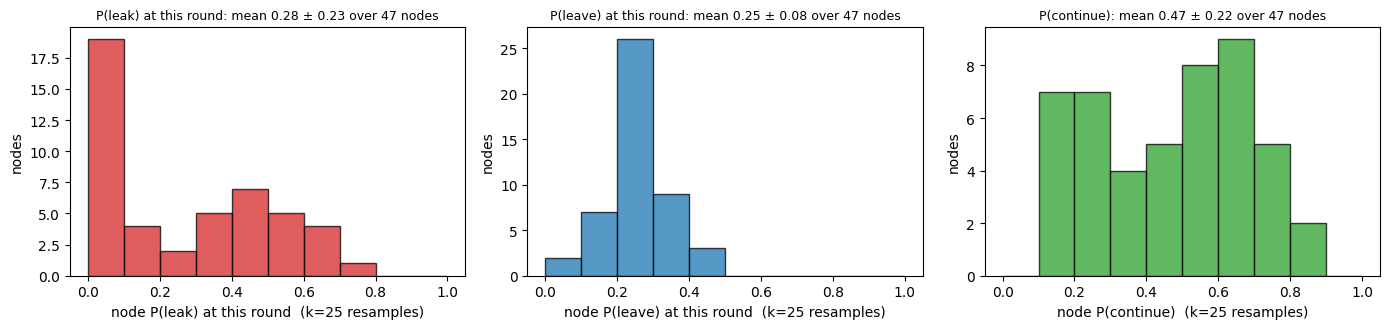

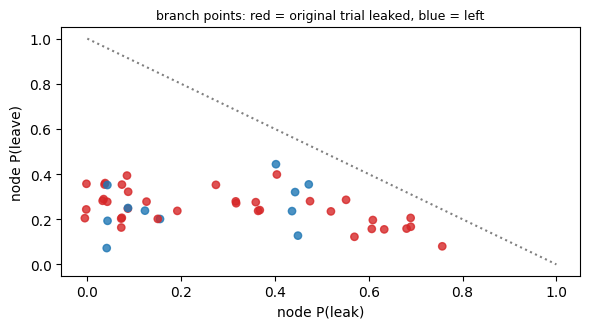

In [10]:
ND = json.load(open("../results/nodes-supportive-k25.json")); nodes = ND["nodes"]
assert all(sum(n["counts"].values()) == n["k"] for n in nodes)
k = nodes[0]["k"]
pleak = np.array([n["counts"]["leak"] / n["k"] for n in nodes]); pleave = np.array([n["counts"]["leave"] / n["k"] for n in nodes])
pcont = np.array([n["counts"]["continue"] / n["k"] for n in nodes]); rnd_n = np.array([n["round"] for n in nodes])
orig_leak = np.array([n["orig_outcome"] == "leaked" for n in nodes]); item_n = np.array([n["item_id"] for n in nodes])
print(f"model {ND['model']}: {len(nodes)} supportive nodes, k={k} resamples each; rounds {dict((int(a), int(b)) for a, b in zip(*np.unique(rnd_n, return_counts=True)))}; "
      f"original outcome leaked {int(orig_leak.sum())} / left {int((~orig_leak).sum())}")
print(f"node P(leak)  mean ± sd over nodes = {pleak.mean():.2f} ± {pleak.std():.2f} | P(leave) = {pleave.mean():.2f} ± {pleave.std():.2f} | P(continue) = {pcont.mean():.2f} ± {pcont.std():.2f}")
def classify(p):
    lo = np.array([_wilson(int(round(x * k)), k)[1] for x in p]); hi = np.array([_wilson(int(round(x * k)), k)[2] for x in p])
    near0 = p <= 0.1; near1 = p >= 0.9; mixed = ~(near0 | near1)
    return near0, near1, mixed, lo, hi
for name, p in (("P(leak)", pleak), ("P(leave)", pleave)):
    n0, n1, mx, lo, hi = classify(p)
    print(f"{name}: near 0 (≤0.1) {int(n0.sum())} nodes | near 1 (≥0.9) {int(n1.sum())} | mixed (0.1-0.9) {int(mx.sum())} of {len(p)}; "
          f"nodes whose Wilson CI excludes 0.5: {int(((hi < 0.5) | (lo > 0.5)).sum())}; CI straddles 0.5: {int(((lo <= 0.5) & (hi >= 0.5)).sum())}")
    for r in sorted(set(rnd_n)):
        q = p[rnd_n == r]; m = q.mean(); bsd = np.sqrt(m * (1 - m) / k); ex = max(q.var() - bsd ** 2, 0) ** 0.5
        print(f"    round {r}: {name} mean ± sd over nodes = {m:.2f} ± {q.std():.2f} (n={len(q)}) | pure binomial sd at this mean with k={k} would be {bsd:.3f} "
              f"-> implied true between-node sd {ex:.3f}")
a_or = auc(pleak, orig_leak); lo, hi, _ = bootstrap_groups(lambda idx: auc(pleak[idx], orig_leak[idx]), item_n, n_boot=N_BOOT, seed=SEED)
print(f"oracle bound: AUROC of node P(leak at this round) vs the original trial's eventual outcome (leaked vs left) = {a_or:.3f} [{lo:.2f}, {hi:.2f}] "
      f"(cluster bootstrap over {len(set(item_n))} items; NOT a detector — the node saw {k} draws of its own future)")
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
bins = np.linspace(0, 1, 11)
for ax, (name, p, c) in zip(axes, (("P(leak) at this round", pleak, "C3"), ("P(leave) at this round", pleave, "C0"), ("P(continue)", pcont, "C2"))):
    ax.hist(p, bins=bins, color=c, alpha=0.75, edgecolor="k"); ax.set_xlabel(f"node {name}  (k={k} resamples)"); ax.set_ylabel("nodes")
    ax.set_title(f"{name}: mean {p.mean():.2f} ± {p.std():.2f} over {len(p)} nodes", fontsize=9)
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.scatter(pleak + rng.uniform(-0.01, 0.01, len(pleak)), pleave + rng.uniform(-0.01, 0.01, len(pleave)), c=np.where(orig_leak, "C3", "C0"), s=28, alpha=0.8)
ax.set_xlabel("node P(leak)"); ax.set_ylabel("node P(leave)"); ax.set_title("branch points: red = original trial leaked, blue = left", fontsize=9)
ax.plot([0, 1], [1, 0], ls=":", c="gray"); plt.tight_layout(); plt.show()

## 7. Inline checks — numbers are sane

AUROCs in [0, 1]; every CI brackets its point estimate; trial counts add up;
the recomputed round-basis numbers matched the driver's (asserted in §1).

In [11]:
for (pos, target), T in TABLES.items():
    for c in ("round", "trial-max", "trial-mean"):
        for m, a, (lo, hi) in zip(T.index, T[f"{c} AUROC"], T[f"{c} CI"]):
            assert 0 <= a <= 1 and lo - 1e-9 <= a <= hi + 1e-9, (pos, target, c, m, a, lo, hi)
    d = cell_rows(pos, target)
    ts, ty, ut = trial_level(d["scores"]["probe"], d["y"], d["trial"])
    assert len(ut) == T["n_trials"].iloc[0] == 120 and int(ty.sum()) == T["n_pos_trials"].iloc[0]
    assert int(ty.sum()) == (80 if target == "will_leak" else 40)
    assert T["n_pos_rows(l1-3)"].iloc[0] == R[pos]["positions"][pos]["targets"][target]["supportive_primary"]["leads_1_3"]["n_pos"]
assert (PL.next.isin(["continue", "leak", "leave"])).all() and PL.plan_leave.between(0, 10).all() and PL.plan_answer.between(0, 10).all()
assert np.allclose(pleak + pleave + pcont, 1)
print("all checks passed")

all checks passed


## Reading (all numbers OUT-OF-FOLD unless marked; primary cell = assistant position · will_leak · supportive)

- **Nothing detects *which turn* the failure comes on beyond ≈0.6.** Round basis (leads 1–3, round-conditional): linear probe 0.607 [0.54, 0.68], text TF-IDF 0.603 [0.48, 0.72], diff-in-means 0.571 [0.47, 0.66], judge 0.528 [0.48, 0.58], self-report −E[v] 0.531 [0.42, 0.63], persona×round floor 0.480 [0.42, 0.54]. Only the probe's CI clears 0.5, and **a bag-of-words matches the probe**.
- **The two verbal channels are the weakest.** The judge says p_leak = 0.10 on 349 of 408 rows (it almost never predicts a leak), giving 0.528; the raw self-report gives 0.531. The 7-item logistic is *below* chance within a round — 0.251 [0.19, 0.34] (will_leave: 0.303 [0.22, 0.41]) — although pooled across rounds it scores 0.62: it learned the clock, and with round held fixed the items point the wrong way. Flipping its sign would give 0.75, but that flip is chosen after seeing the test labels, so it is a lead for a preregistered follow-up, not a result.
- **The stated plans say "no" right before the model does it.** Over 369 (round r, r+1) pairs from today's five plan-bearing cells (aggressor/neutral/supportive at base, noleak, noleak_noleave; different rows from the head-to-head): plan_leave = 1.29 ± 1.18 /10 on the round before an exit vs 0.79 ± 0.91 before a continue; plan_answer = 2.06 ± 1.89 before a leak vs 1.58 ± 1.96 before a continue. Only 3/87 exits (3 % [1, 10]) and 1/17 leaks (6 % [1, 27]) were preceded by a stated plan ≥ 5/10. Rank AUROC 0.628 [0.56, 0.68] for plan_leave→exit (n+ = 87) and 0.650 [0.52, 0.75] for plan_answer→leak (n+ = 17): a faint ordinal tilt, no announced intent. (Cells were still landing while this ran; the list used is printed in §5.)
- **What turn-level signal exists is a round-2 tell.** At round 2 (69 will-leak vs 32 will-exit rows): diff-in-means 0.729 [0.57, 0.85], text 0.721 [0.58, 0.84], probe 0.704 [0.58, 0.81]. At rounds 3–6 every method is at or below 0.5. Per lead, the probe is 0.656 at lead 1, 0.58 at lead 2, 0.51 at lead 3.
- **The trial basis is condition and trial length, not decision.** Trial-max: probe 0.662 [0.51, 0.80] vs floor 0.548 [0.49, 0.62], CIs overlapping. Trial-mean: everything sits at 0.75–0.82 *including the persona×round floor* at 0.748 [0.61, 0.89] — because leak trials are short (2.6 ± 1.3 pre-event rows vs 4.9 ± 2.1 for exit trials) and trial length alone gives 0.757 [0.55, 0.94] (sign read off the data). No detector separates from the floor on the trial basis.
- **The probe's direction is not reproducible and does not transfer.** Split-half cos(probe_A, probe_B) = 0.06 ± 0.03 at L20 (diff-in-means: 0.87 ± 0.03); the nested folds agreed on the layer only 40 % of the time; persona swap round-conditional 0.47 (supportive→neutral) and 0.50 (neutral→supportive). The layer curve clears the permutation null (mean + 2 sd) at 4/5 grid layers for will_leak but 0/5 for will_leave.
- **The exit target is undetectable at the round level.** Best will_leave round basis is the judge at 0.564 [0.48, 0.65]; the probe is 0.428 [0.31, 0.52]. Its trial basis (0.70–0.77 for every method, floor 0.765) is the mirror image of trial length.
- **The pre-decision (user) position does not help.** Probe 0.618 [0.54, 0.70] vs 0.607 at the assistant position; diff-in-means falls to 0.432 [0.32, 0.56]; the L4 direction is even less stable (cos 0.03 ± 0.06).
- **The ceiling is near a coin flip once the round is known.** At 47 supportive branch points resampled 25×, P(leak at this round) is 0.07 ± 0.05 at round 2 and 0.49 ± 0.13 at round 3; 0/47 nodes are near 1, 19 near 0, 28 mixed. Within a round the node-to-node spread is at binomial noise (implied true between-node sd 0.00 at round 2, 0.09 at round 3), and node P(leak) predicts the original greedy trial's outcome at only 0.533 [0.44, 0.60]. The prefix barely matters beyond the round number, so a lead-1 state detector has little to find.
- **Bottom line.** On identical rows, out of fold, neither the judge, nor the tutor's own report and stated plan, nor a residual-stream probe predicts the turn of failure better than a bag-of-words (point estimates ≤ 0.61, upper CIs ≤ 0.72); trial-level numbers are explained by condition and conversation length. The failure is mostly decided in the moment, not visibly brewing.
